In [2]:
#import esmpy
from figures_functions import *
gc.collect()
from matplotlib import colors
from matplotlib.lines import Line2D

### Models

In [5]:
# CMIP6
institution=['BCC','CCCma','CNRM','CSIRO','UK','MPI','CESM','NCC','NOAA-GFDL']
model=['BCC-CSM2-MR','CanESM5','CNRM-ESM2-1','ACCESS-ESM1-5','UKESM1-0-LL','MPI-ESM1-2-LR','CESM2','NorESM2-LM','NOAA-GFDL-ESM4','Ensemble']
model2=['BCC','CanESM5','CNRM','ACCESS','UKESM1','MPI','CESM2','NorESM2','GFDL','Ensemble']
modelnep=model.copy(); modelnep.remove('CESM2')
modelnbp=model.copy(); modelnbp.remove('BCC-CSM2-MR')

modelnep2=model2.copy(); modelnep2.remove('CESM2')
modelnbp2=model2.copy(); modelnbp2.remove('BCC')

# Models with nep and nbp.
modnep_cmip6=np.arange(len(model)); modnbp_cmip6=np.arange(len(model))
modnep_cmip6=np.delete(modnep_cmip6,[6],axis=0); 
modnbp_cmip6=np.delete(modnbp_cmip6,[0],axis=0)
#modelnep=model2


# TRENDY
modnep_trendy=['CABLE-POP','CLASSIC','CLM5.0','DLEM','ED','ELM','IBIS','iMAPLE','ISAM','ISBACTRIP','JSBACH','JULES','LPJml','LPJwsl','LPX','OCN','ORCHIDEE','SDGVM','VISIT','VISIT-UT','Ensemble']
modnep_trendy.remove('VISIT')
modnbp_trendy=['CABLE-POP','CLASSIC','CLM5.0','ED','ELM','IBIS','iMAPLE','ISAM','ISBACTRIP','JSBACH','JULES','LPJwsl','LPX','OCN','ORCHIDEE','SDGVM','VISIT','VISIT-UT','Ensemble']
modnbp_trendy.remove('VISIT')

### Accumulation at the end of the time series NEP (CMIP6 and TRENDY)

/tmp/ipykernel_24196/1629819147.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CS["time"]=CS["time"].astype("datetime64[ns]")
/tmp/ipykernel_24196/1629819147.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CS["time"]=CS["time"].astype("datetime64[ns]")
/tmp/ipykernel_24196/1629819147.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

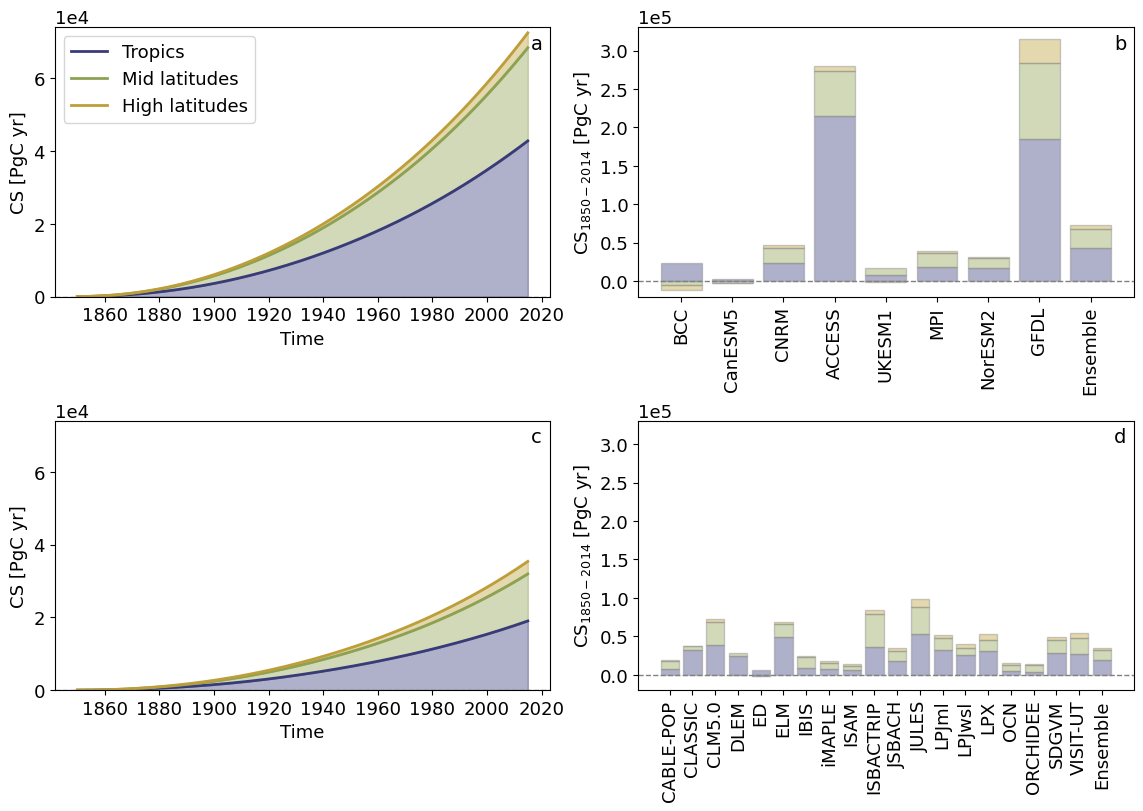

In [6]:
plt.rcParams.update({'font.size':13})
tit=['glob','trop','mid','high']
titles=['Global','Tropics','Mid latitudes','High latitudes']
def get_cumulated_array(data, **kwargs):
    cum = data.clip(**kwargs)
    cum = np.cumsum(cum, axis=0)
    d = np.zeros(np.shape(data))
    d[1:] = cum[:-1]
    return d  

cmap=plt.cm.tab20b
colorv=cmap([0,0.25,0.45])
 
fig4,ax=plt.subplots(ncols=2,nrows=2,figsize=[8*np.sqrt(2),16/2],constrained_layout=True)


for i in range (2):
    ens_nep=np.zeros(len(titles));ens_nbp=np.zeros(len(titles))
    var='NEP'
    if i==0:
        mod=modnep_cmip6
        pp='CMIP6'
        n=9
        n2=2
        #models=modelnep
        models2=modelnep2
    if i==1: 
        mod=modnep_trendy
        pp='TRENDY'
        n=20
        n2=1
#         models=modelnbp
        models2=mod
    nf=len(mod)

    ## Preparation
    data=np.zeros([3,n])
    for k in range(1,4):
        if pp=='TRENDY':
            base_path='/home/_ehoyos/ResultsCS/Lat/'
            path = glob.glob(f"{base_path}{var}_cs_cum_lat_{tit[k]}_TRENDY*.csv")
            path=sorted(path)
            dfs = []
            for f1, f in enumerate(path):
                df = pd.read_csv(f)
                if f1 > 0:df = df.drop(columns=['time'])
                dfs.append(df)
            CSt=pd.concat(dfs, axis=1)
            CSt.drop('VISIT', axis=1, inplace=True) 
        if pp=='CMIP6':
            CSt=pd.read_csv('~/ResultsCS/Lat/'+var+'_cs_cum_lat_'+tit[k]+'_'+pp+'.csv')
        data[k-1,:]=CSt.values[-1:][0][n2:]/1e+12

    cumulated_data = get_cumulated_array(data, min=0)
    cumulated_data_neg = get_cumulated_array(data, max=0)
    row_mask = (data<0)
    cumulated_data[row_mask] = cumulated_data_neg[row_mask]
    data_stack = cumulated_data
    data_shape = np.shape(data)

    for k in range(1,len(titles)): # spatial divisions.
    #for k in range(1,2):
        if pp=='CMIP6':CSt=pd.read_csv('~/ResultsCS/Lat/'+var+'_cs_cum_lat_'+tit[k]+'_'+pp+'.csv')
        if pp=='TRENDY':
            path = glob.glob(f"{base_path}{var}_cs_cum_lat_{tit[k]}_TRENDY*.csv")
            path=sorted(path)
            dfs = []
            for f1, f in enumerate(path):
                df = pd.read_csv(f)
                if f1 > 0:df = df.drop(columns=['time'])
                dfs.append(df)
            CSt=pd.concat(dfs, axis=1)
            CSt.drop('VISIT',axis=1, inplace=True) 
        CS=CSt[['time','mmean']]
        CS["time"]=CS["time"].astype("datetime64[ns]")
#     #CS["time"]=CS["time"].apply(pd.to_datetime)
        if k==1: b=np.zeros(len(CS.time)); b2=0
        ax[i,0].plot(CS.time.values,(CS.mmean.values+b)/1e+12,color=colorv[k-1],linewidth=2,label=titles[k])
        ax[i,0].fill_between(CS.time.values,b/1e+12,(CS.mmean.values+b)/1e+12,color=colorv[k-1],alpha=0.4)
        b=b+CS.mmean.values
    
    for k in np.arange(0,data_shape[0]):
        ax[i,1].bar(models2,data[k,:],bottom=data_stack[k,:],color=colorv[k],alpha=0.4,edgecolor='gray')
        

    ax[i,0].axhline(y=0,color='gray',ls='--',linewidth=1)    
  
    ax[i,0].set_xlabel("Time")
    ax[i,0].set_ylabel("CS [PgC yr]")
    ax[i,0].ticklabel_format(axis='y', style='',scilimits=[10,20])
    ax[i,0].set_ylim(0,7.4e4)


    ax[i,1].axhline(y=0,color='gray',ls='--',linewidth=1)
    ax[i,1].set_ylabel("CS$_{1850-2014}$ [PgC yr]")
    ax[i,1].ticklabel_format(axis='y', style='',scilimits=[10,200])
    ax[i,1].tick_params(axis='x',labelrotation=90)
    ax[i,1].set_ylim(-0.2e5,3.3e5)

    if i==0:
        ax[i,0].text(0.96,0.92,'a',transform=ax[i,0].transAxes,fontsize=14)  
        ax[i,1].text(0.96,0.92,'b',transform=ax[i,1].transAxes,fontsize=14)
    if i==1:
        ax[i,0].text(0.96,0.92,'c',transform=ax[i,0].transAxes,fontsize=14)  
        ax[i,1].text(0.96,0.92,'d',transform=ax[i,1].transAxes,fontsize=14)
ax[0,0].legend()
# # # ax[1].text(1860, -0.2, 'a',fontsize=15)
# # # #ax[2].text(-0.75,78,'d',fontsize=15)

fig4.savefig('/home/_ehoyos/cmip6stop/CS/Figures/NEP_CMIP6_TRENDY_CS_time_final_res.pdf',bbox_inches="tight")      

In [7]:
var='NEP'
titv=tit[3]
#CMIP global
CSt=pd.read_csv('~/ResultsCS/Lat/'+var+'_cs_cum_lat_'+titv+'_'+'CMIP6.csv')
CSCMIPNEP=CSt['mmean'].values[-1]/1e12

#trendy global
path=glob.glob(f"{base_path}{var}_cs_cum_lat_{titv}_TRENDY*.csv")
path=sorted(path)
dfs = []
for f1, f in enumerate(path):
    df = pd.read_csv(f)
    if f1 > 0:df = df.drop(columns=['time'])
    dfs.append(df)
CSt=pd.concat(dfs, axis=1)
CSt.drop('VISIT',axis=1, inplace=True) 
CSTRENDYNEP=CSt['mmean'].values[-1]/1e12

In [54]:
CSCMIPNEP

4087.66109648358

In [55]:
CSTRENDYNEP

3439.084499596824

### Accumulation at the end of the time series NBP (CMIP6 and TRENDY)

/tmp/ipykernel_24196/645731817.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CS["time"]=CS["time"].astype("datetime64[ns]")
/tmp/ipykernel_24196/645731817.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CS["time"]=CS["time"].astype("datetime64[ns]")
/tmp/ipykernel_24196/645731817.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

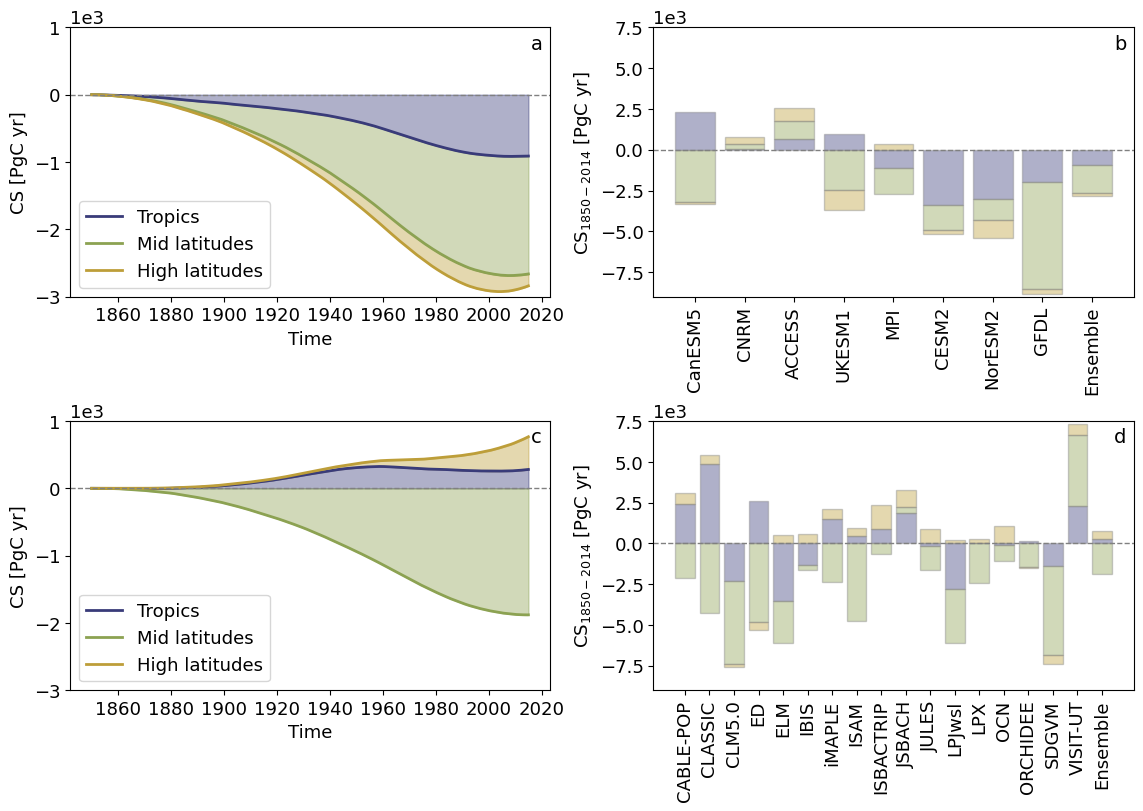

In [8]:
plt.rcParams.update({'font.size':13})
tit=['glob','trop','mid','high']
titles=['Global','Tropics','Mid latitudes','High latitudes']
def get_cumulated_array(data, **kwargs):
    cum = data.clip(**kwargs)
    cum = np.cumsum(cum, axis=0)
    d = np.zeros(np.shape(data))
    d[1:] = cum[:-1]
    return d  

cmap=plt.cm.tab20b
colorv=cmap([0,0.25,0.45])
 
fig4,ax=plt.subplots(ncols=2,nrows=2,figsize=[8*np.sqrt(2),16/2],constrained_layout=True)


for i in range (2):
    ens_nep=np.zeros(len(titles));ens_nbp=np.zeros(len(titles))
    var='NBP'
    if i==0:
        mod=modnbp_cmip6
        pp='CMIP6'
        n=9
        n2=2
        #models=modelnep
        models2=modelnbp2
    if i==1: 
        mod=modnbp_trendy
        pp='TRENDY'
        n=18
        n2=1
#         models=modelnbp
        models2=mod
    nf=len(mod)

    ## Preparation
    data=np.zeros([3,n])
    for k in range(1,4):
        if pp=='TRENDY':
            path = glob.glob(f"{base_path}{var}_cs_cum_lat_{tit[k]}_TRENDY*.csv")
            path=sorted(path)
            dfs = []
            for f1, f in enumerate(path):
                df = pd.read_csv(f)
                if f1 > 0:df = df.drop(columns=['time'])
                dfs.append(df)
            CSt=pd.concat(dfs, axis=1)
            CSt.drop('VISIT', axis=1, inplace=True) 
        if pp=='CMIP6':
            CSt=pd.read_csv('~/ResultsCS/Lat/'+var+'_cs_cum_lat_'+tit[k]+'_'+pp+'.csv')
        data[k-1,:]=CSt.values[-1:][0][n2:]/1e+12

    cumulated_data = get_cumulated_array(data, min=0)
    cumulated_data_neg = get_cumulated_array(data, max=0)
    row_mask = (data<0)
    cumulated_data[row_mask] = cumulated_data_neg[row_mask]
    data_stack = cumulated_data
    data_shape = np.shape(data)

    #for k in range(1,len(titles)): # spatial divisions.
    n=0
    for k in range(1,4):
        if pp=='CMIP6':CSt=pd.read_csv('~/ResultsCS/Lat/'+var+'_cs_cum_lat_'+tit[k]+'_'+pp+'.csv')
        if pp=='TRENDY':
            path = glob.glob(f"{base_path}{var}_cs_cum_lat_{tit[k]}_TRENDY*.csv")
            path=sorted(path)
            dfs = []
            for f1, f in enumerate(path):
                df = pd.read_csv(f)
                if f1 > 0:df = df.drop(columns=['time'])
                dfs.append(df)
            CSt=pd.concat(dfs, axis=1)
            CSt.drop('VISIT',axis=1, inplace=True) 
        CS=CSt[['time','mmean']]
        CS["time"]=CS["time"].astype("datetime64[ns]")
#     #CS["time"]=CS["time"].apply(pd.to_datetime)
        if k==1: b=np.zeros(len(CS.time))
        x2=0 if CS.mmean.values[-1]<0 else 1 
        if k>1:
            if x1 != x2: 
                if n==0:
                    b2=b
                    b=np.zeros(len(CS.time))
                    
                else: b=b2
                n=n+1
            
        ax[i,0].plot(CS.time.values,(CS.mmean.values+b)/1e+12,color=colorv[k-1],linewidth=2,label=titles[k])
        ax[i,0].fill_between(CS.time.values,b/1e+12,(CS.mmean.values+b)/1e+12,color=colorv[k-1],alpha=0.4)
    
        x1=0 if CS.mmean.values[-1]<0 else 1
        b=b+CS.mmean.values

    for k in np.arange(0,data_shape[0]):
        ax[i,1].bar(models2,data[k,:],bottom=data_stack[k,:],color=colorv[k],alpha=0.4,edgecolor='gray')

    ax[i,0].axhline(y=0,color='gray',ls='--',linewidth=1)    
    ax[i,0].legend()
    ax[i,0].set_xlabel("Time")
    ax[i,0].set_ylabel("CS [PgC yr]")
    ax[i,0].ticklabel_format(axis='y', style='',scilimits=[10,20])
    ax[i,0].set_ylim(-3e3,1e3)


    ax[i,1].axhline(y=0,color='gray',ls='--',linewidth=1)
    ax[i,1].set_ylabel("CS$_{1850-2014}$ [PgC yr]")
    ax[i,1].ticklabel_format(axis='y', style='',scilimits=[10,200])
    ax[i,1].tick_params(axis='x',labelrotation=90)
    ax[i,1].set_ylim(-9e3,7.5e3)

    if i==0:
        ax[i,0].text(0.96,0.92,'a',transform=ax[i,0].transAxes,fontsize=14)  
        ax[i,1].text(0.96,0.92,'b',transform=ax[i,1].transAxes,fontsize=14)
    if i==1:
        ax[i,0].text(0.96,0.92,'c',transform=ax[i,0].transAxes,fontsize=14)  
        ax[i,1].text(0.96,0.92,'d',transform=ax[i,1].transAxes,fontsize=14)

# # # ax[1].text(1860, -0.2, 'a',fontsize=15)
# # # #ax[2].text(-0.75,78,'d',fontsize=15)

fig4.savefig('/home/_ehoyos/cmip6stop/CS/Figures/NBP_CMIP6_TRENDY_CS_time_final_res.pdf',bbox_inches="tight")    

In [9]:
var='NBP'
#CMIP global
titv=tit[3]
CSt=pd.read_csv('~/ResultsCS/Lat/'+var+'_cs_cum_lat_'+titv+'_'+'CMIP6.csv')
CSCMIPNBP=CSt['mmean'].values[-1]/1e12

#trendy global
path=glob.glob(f"{base_path}{var}_cs_cum_lat_{titv}_TRENDY*.csv")
path=sorted(path)
dfs = []
for f1, f in enumerate(path):
    df = pd.read_csv(f)
    if f1 > 0:df = df.drop(columns=['time'])
    dfs.append(df)
CSt=pd.concat(dfs, axis=1)
CSt.drop('VISIT',axis=1, inplace=True) 
CSTRENDYNBP=CSt['mmean'].values[-1]/1e12

In [57]:
CSCMIPNBP

-176.99627737499026

In [58]:
CSTRENDYNBP

486.1402143156117

In [59]:
CSTRENDYNEP-CSTRENDYNBP

2952.9442852812126

## Comparison single and double integral

/tmp/ipykernel_24196/446291043.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CS["time"]=CS["time"].astype("datetime64[ns]")
/tmp/ipykernel_24196/446291043.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CS["time"]=CS["time"].astype("datetime64[ns]")
/home/_ehoyos/anaconda3/envs/bgc_md2/lib/python3.9/site-packages/matplotlib/axis.py:125: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if labelcolor == 'inherit':


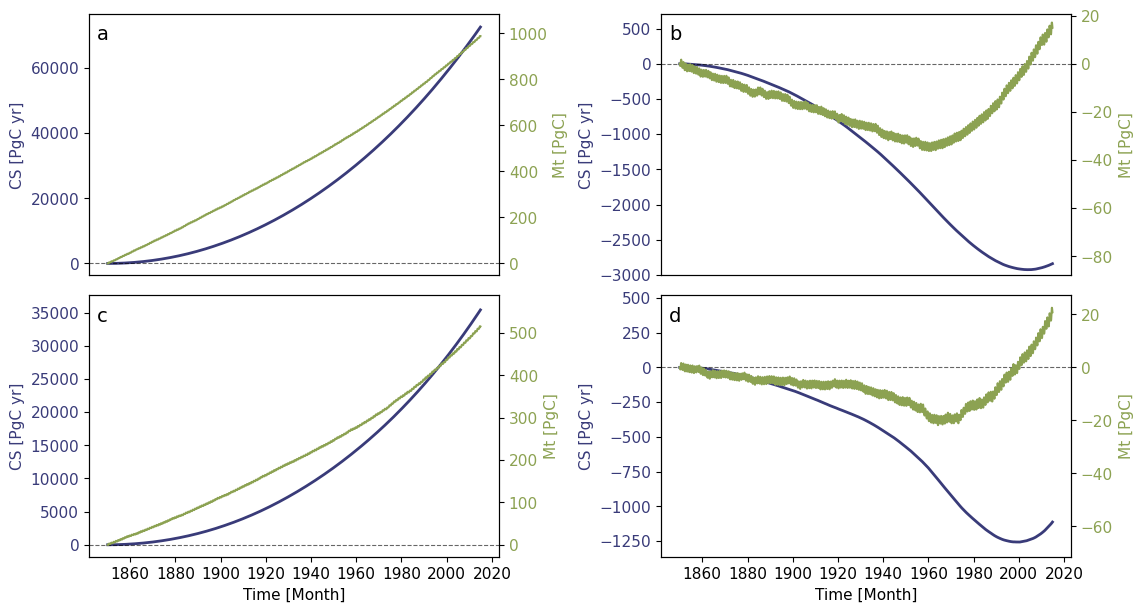

In [190]:
plt.rcParams.update({'font.size':11})
cmap=plt.cm.tab20b
colorv=cmap([0,0.25,0.45])
tit=['glob','trop','mid','high']
bb=['a','b','c','d']
fig5,ax=plt.subplots(ncols=2,nrows=2,figsize=[8*np.sqrt(2),6],constrained_layout=True)
k=0
var=['NEP','NBP']; var2=['nep','nbp']
for i in range(2): # Products
    for j in range(2): # variables
# files
        if i==0:
            CSt=pd.read_csv('~/ResultsCS/Lat/'+var[j]+'_cs_cum_lat_'+tit[k]+'_CMIP6.csv')
            CSt=CSt[['time','mmean']]
            Mt=xr.open_dataset('~/ResultsCS/MT_'+var2[j]+'_CMIP6_w.nc')
        if i==1:
            path = glob.glob(f"{base_path}{var[j]}_cs_cum_lat_{tit[k]}_TRENDY*.csv")
            path=sorted(path)
            dfs = []
            for f1, f in enumerate(path):
                df = pd.read_csv(f)
                if f1 > 0:df = df.drop(columns=['time'])
                dfs.append(df)
            CSt=pd.concat(dfs, axis=1)
            Mt=xr.open_dataset('~/ResultsCS/MT_'+var2[j]+'_TRENDY_w_1850-2014.nc')
        CS=CSt[['time','mmean']]
        CS["time"]=CS["time"].astype("datetime64[ns]")
        Mt=Mt['mmean']
        
        
#Mt spatial integration   
        if k==0:Mts=Mt # Global
        if k==1:mask=((Mt.lat <= 22.5)&(Mt.lat >= -22.5)) # Tropics
        if k==3:mask=(Mt.lat >= 55.0) # high latitudes
        if k!=0: Mts=Mt.where(mask,drop=True)
        if k==2:
            mask1=(Mt.lat > 22.5)&(Mt.lat < 55.0) # mid latitudes.
            mask2=(Mt.lat < -22.5) # mid latitudes.
            w1=Mt.where(mask1,drop=True)
            w2=Mt.where(mask2,drop=True)
            Mts=xr.concat([w1,w2],dim='lat')
        Mts_xy=calc_spatial_integral(Mts)    

        ax[i,j].plot(CS.time.values,(CS[CS.columns[1]].values)/1e+12,linewidth=2,color=colorv[0])
        ax[i,j].set_ylabel('CS [PgC yr]',color=colorv[0])
        ax[i,j].tick_params(axis='y',labelcolor=colorv[0])
        ax2=ax[i,j].twinx()
    
        ax2.plot(Mts_xy.time.values,Mts_xy/1e12,color=colorv[1])
        ax2.set_ylabel('Mt [PgC]', color=colorv[1])
        ax2.tick_params(axis='y',labelcolor=colorv[1])

# make the zeros of both variables coincide
        y1_min, y1_max = ax[i,j].get_ylim()
        y2_min, y2_max = ax2.get_ylim()
        pos1 = (0 - y1_min) / (y1_max - y1_min)
        pos2 = (0 - y2_min) / (y2_max - y2_min)
        zero_pos = (pos1 + pos2) / 2

        range1 = y1_max - y1_min+500
        range2 = y2_max - y2_min+50

        ax[i,j].set_ylim(0 - zero_pos * range1, 0 + (1-zero_pos) * range1)
        ax2.set_ylim(0 - zero_pos * range2, 0 + (1-zero_pos) * range2)
        ax[i,j].axhline(0, color='k', lw=0.8, alpha=0.6,ls='--')
    
        ax[i,j].text(0.02,0.9,bb[2*i+j],transform=ax[i,j].transAxes,fontsize=14)

ax[0,0].set_xticks([]); ax[0,1].set_xticks([])  
ax[1,0].set_xlabel('Time [Month]'); ax[1,1].set_xlabel('Time [Month]')
# plt.show()
fig5.savefig('/home/_ehoyos/cmip6stop/CS/Figures/CMIP6_TRENDY_comparison_CS_Mt.pdf',bbox_inches="tight")

## Sensibility to initial time (rolling window)

/tmp/ipykernel_24196/2343125397.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CS["time"]=CS["time"].astype("datetime64[ns]")
/tmp/ipykernel_24196/2343125397.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CS["time"] = pd.to_datetime(CS["time"])
/tmp/ipykernel_24196/2343125397.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

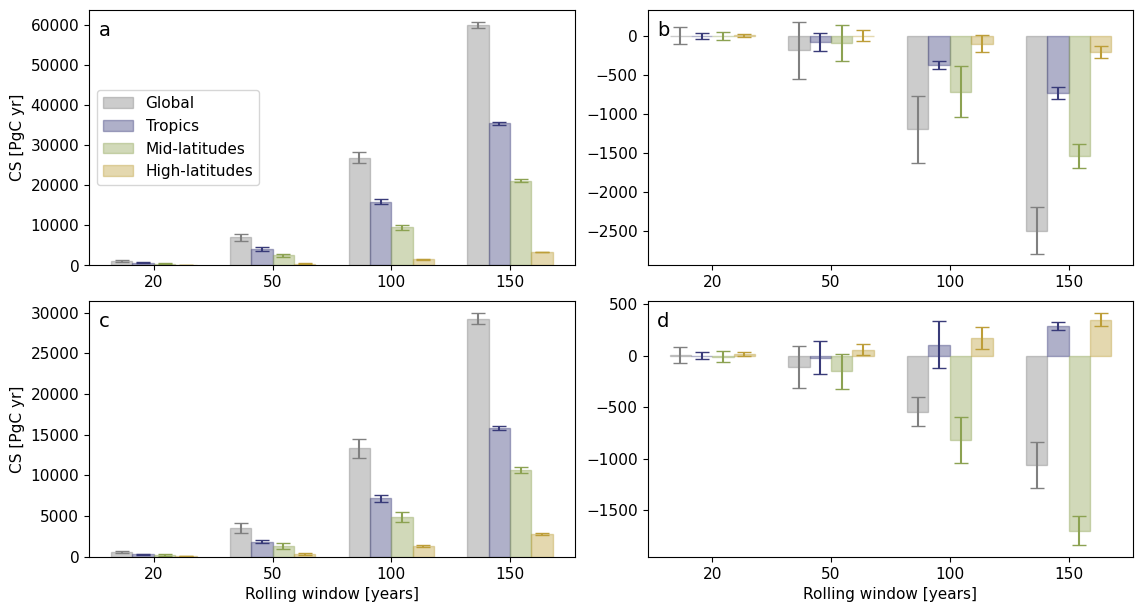

In [214]:
import matplotlib.colors as mcolors
plt.rcParams.update({'font.size':11})
cmap=plt.cm.tab20b
colorv=cmap([0,0.25,0.45])
gray_color = np.array(mcolors.to_rgba('gray'))
colorv = np.vstack(([gray_color], colorv))
tit=['glob','trop','mid','high']
regions = ['Global', 'Tropics', 'Mid-latitudes', 'High-latitudes']
bb=['a','b','c','d']
fig5,ax=plt.subplots(ncols=2,nrows=2,figsize=[8*np.sqrt(2),6],constrained_layout=True)
var=['NEP','NBP']; var2=['nep','nbp']
window_years = [20, 50, 100, 150]
# window_years = [20,150]
all_data = {}
bar_width = 0.18                    # Width of each individual bar
for i in range(2): # Products
    for j in range(2): # variables
        for k in range(len(tit)):
# files
            if i==0:
                CSt=pd.read_csv('~/ResultsCS/Lat/'+var[j]+'_cs_cum_lat_'+tit[k]+'_CMIP6.csv')
                CSt=CSt[['time','mmean']]
                Mt=xr.open_dataset('~/ResultsCS/MT_'+var2[j]+'_CMIP6_w.nc')
            if i==1:
                path = glob.glob(f"{base_path}{var[j]}_cs_cum_lat_{tit[k]}_TRENDY*.csv")
                path=sorted(path)
                dfs = []
                for f1, f in enumerate(path):
                    df = pd.read_csv(f)
                    if f1 > 0:df = df.drop(columns=['time'])
                    dfs.append(df)
                CSt=pd.concat(dfs, axis=1)
                Mt=xr.open_dataset('~/ResultsCS/MT_'+var2[j]+'_TRENDY_w_1850-2014.nc')
            CS=CSt[['time','mmean']]
            CS["time"]=CS["time"].astype("datetime64[ns]")
            Mt=Mt['mmean']
            CS["time"] = pd.to_datetime(CS["time"])
            CS=CS.set_index("time")
            CS_xr=CS.to_xarray()
            mtf=CS_xr.differentiate("time", datetime_unit='D')*30.4*12
            nn=mtf.differentiate("time", datetime_unit='D')*30.4*12
# #Mt spatial integration   
#             if k==0:Mts=Mt # Global
#             if k==1:mask=((Mt.lat <= 22.5)&(Mt.lat >= -22.5)) # Tropics
#             if k==3:mask=(Mt.lat >= 55.0) # high latitudes
#             if k!=0:Mts=Mt.where(mask,drop=True)
#             if k==2:
#                 mask1=(Mt.lat > 22.5)&(Mt.lat < 55.0) # mid latitudes.
#                 mask2=(Mt.lat < -22.5) # mid latitudes.
#                 w1=Mt.where(mask1,drop=True)
#                 w2=Mt.where(mask2,drop=True)
#                 Mts=xr.concat([w1,w2],dim='lat')
#             Mts_xy=calc_spatial_integral(Mts)   
            
    
#     mtf=Mts_xy.differentiate("time", datetime_unit='D')*30.4*12
#             nn=Mts_xy.differentiate("time", datetime_unit='D')*30.4*12
            
            window_results = {}

            for years in window_years:
                months_in_window = years * 12
                final_accumulated_values = []
    
# Calculate the number of possible windows across the 1980 months
                total_steps = len(nn.time) - months_in_window + 1
    
                for ii in range(total_steps):
# Slice the temporal segment for the current window
                    time_slice = nn.isel(time=slice(ii, ii + months_in_window))

                    Mtf=time_slice.cumulative_integrate("time",datetime_unit='D')/30.4/12 
                    CSf=Mtf.cumulative_integrate("time",datetime_unit='D')/30.4/12 
        
# Extract and store the final endpoint value of this specific window
                    final_value = CSf.mmean.isel(time=-1).item()
                    final_accumulated_values.append(final_value)
                final_accumulated_values = np.array(final_accumulated_values)
    
# Compute and store the required statistical values
                window_results[years] = {
                    "mean": np.mean(final_accumulated_values),
                    "std_dev": np.std(final_accumulated_values),
                    "window_count": len(final_accumulated_values)
                }
                
            all_data[tit[k]] = window_results
# Plot  
        means_list = []; stds_list = []
        for years in window_years:
            year_means = []
            year_stds = []
            for region in tit:
                year_means.append(all_data[region][years]["mean"])
                year_stds.append(all_data[region][years]["std_dev"])
            means_list.append(year_means)
            stds_list.append(year_stds)

        means = np.array(means_list)
        stds = np.array(stds_list)
        x = np.arange(len(window_years))  # Base X locations for the windows

        for ii, region in enumerate(regions):
    # Calculate horizontal offset for each latitudinal bar to avoid overlap
            offset = (ii - len(regions)/2) * bar_width + bar_width/2
    
            ax[i,j].bar(x + offset, means[:, ii]/1e12, width=bar_width, label=region,color=colorv[ii],
            yerr=stds[:, ii]/1e12, capsize=5, ecolor=colorv[ii], edgecolor=colorv[ii], linewidth=1, alpha=0.4)

        ax[i,j].set_xticks(x)
        ax[i,j].set_xticklabels(window_years, fontsize=11)
        if i==1: ax[i,j].set_xlabel('Rolling window [years]')
        if j==0: ax[i,j].set_ylabel('CS [PgC yr]')
        if (i==0) & (j==0): ax[i,j].legend(loc='center left')
        ax[i,j].text(0.02,0.9,bb[2*i+j],transform=ax[i,j].transAxes,fontsize=14)

fig5.savefig('/home/_ehoyos/cmip6stop/CS/Figures/Rolling_window_CS.pdf',bbox_inches="tight")